# Modelamiento
Entrenamiento de modelos.

In [7]:
import matplotlib
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
import os
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 10)
PALETA_ROSA = ["#FF1493", "#FF69B4", "#FFB6C1", "#FFC0CB", "#DB7093"]
sns.set_palette(PALETA_ROSA)
pd.set_option("display.max_columns", None)
print("Librerias importadas")

Librerias importadas


## 1. Datos

In [8]:
X_train=pd.read_csv("../data/X_train.csv")
X_test=pd.read_csv("../data/X_test.csv")
y_train=pd.read_csv("../data/y_train.csv").values.ravel()
y_test=pd.read_csv("../data/y_test.csv").values.ravel()
print("X_train: %s" % str(X_train.shape))
print("X_test: %s" % str(X_test.shape))
with open("../data/feature_names.pkl","rb") as f:
    fn=pickle.load(f)
print("Features: %d" % len(fn))
with open("../data/scaler.pkl","rb") as f:
    sc=pickle.load(f)
print("Scaler OK")

X_train: (9884, 45)
X_test: (2514, 45)
Features: 45
Scaler OK


In [9]:
# VERIFICACIÓN ANTI-LEAKAGE — correr siempre antes de entrenar
print("=== VERIFICACIÓN DE COLUMNAS ===")
cols_leakage = ['dec','dec_o','like','prob','like_o','prob_o',
                'attr_o','sinc_o','intel_o','fun_o','amb_o','shar_o',
                'int_corr','match_es']
encontradas = [c for c in cols_leakage if c in X_train.columns]
if encontradas:
    print("🚨 LEAKAGE DETECTADO: %s" % encontradas)
    print("   Detener y corregir notebook 1 antes de continuar")
    raise ValueError("LEAKAGE en X_train — ver columnas arriba")
else:
    print("✅ Sin leakage detectado")
    print("   Columnas en X_train: %d" % X_train.shape[1])
    print("   Train size: %d | Test size: %d" % (len(X_train), len(X_test)))
    print("   Train match rate: %.3f (SMOTE)" % y_train.mean())
    print("   Test match rate:  %.3f (real)"  % y_test.mean())

=== VERIFICACIÓN DE COLUMNAS ===
✅ Sin leakage detectado
   Columnas en X_train: 45
   Train size: 9884 | Test size: 2514
   Train match rate: 0.500 (SMOTE)
   Test match rate:  0.157 (real)


## 2. Modelos

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time
mo={"Arbol":DecisionTreeClassifier(random_state=42),
    "MLP":MLPClassifier(random_state=42,max_iter=1000),
    "SVM":SVC(random_state=42,probability=True),
    "KNN":KNeighborsClassifier(),
    "RF":RandomForestClassifier(random_state=42),
    "XGB":XGBClassifier(random_state=42,eval_metric="logloss",use_label_encoder=False),
    "GB":GradientBoostingClassifier(random_state=42)}
cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
scoring={"accuracy":make_scorer(accuracy_score),"precision":make_scorer(precision_score),"recall":make_scorer(recall_score),"f1":make_scorer(f1_score),"roc_auc":make_scorer(roc_auc_score)}
res=[]
cvsc={}
print("Entrenando 7 modelos 10-fold CV...")
for n,m in mo.items():
    print("  %s..." % n)
    t0=time.time()
    r=cross_validate(m,X_train,y_train,cv=cv,scoring=scoring,return_train_score=True)
    t=time.time()-t0
    res.append({"Modelo":n,"Accuracy_mean":r["test_accuracy"].mean(),"Accuracy_std":r["test_accuracy"].std(),"Precision_mean":r["test_precision"].mean(),"Precision_std":r["test_precision"].std(),"Recall_mean":r["test_recall"].mean(),"Recall_std":r["test_recall"].std(),"F1_mean":r["test_f1"].mean(),"F1_std":r["test_f1"].std(),"ROC_AUC_mean":r["test_roc_auc"].mean(),"ROC_AUC_std":r["test_roc_auc"].std(),"Tiempo":t})
    cvsc[n]=r["test_roc_auc"]
    print("    ROC-AUC: %.4f" % res[-1]["ROC_AUC_mean"])
dfr=pd.DataFrame(res).sort_values("ROC_AUC_mean",ascending=False)
print("\nTabla comparativa:")
dfr[["Modelo","Accuracy_mean","Precision_mean","Recall_mean","F1_mean","ROC_AUC_mean"]]

Entrenando 7 modelos 10-fold CV...
  Arbol...
    ROC-AUC: 0.8179
  MLP...
    ROC-AUC: 0.8904
  SVM...
    ROC-AUC: 0.9067
  KNN...
    ROC-AUC: 0.5784
  RF...
    ROC-AUC: 0.9093
  XGB...
    ROC-AUC: 0.9066
  GB...
    ROC-AUC: 0.9023

Tabla comparativa:


,Modelo,Accuracy_mean,Precision_mean,Recall_mean,F1_mean,ROC_AUC_mean
4,RF,0.909347,0.984202,0.832052,0.901612,0.909348
2,SVM,0.906719,0.914873,0.897003,0.905769,0.906717
5,XGB,0.906616,0.988165,0.823148,0.897933,0.906616
6,GB,0.902266,0.986761,0.815460,0.892832,0.902265
1,MLP,0.890427,0.843418,0.959122,0.897494,0.890424
0,Arbol,0.817888,0.805459,0.838322,0.821424,0.817886
3,KNN,0.578412,0.542713,0.996965,0.702818,0.578413


## 3. ROC

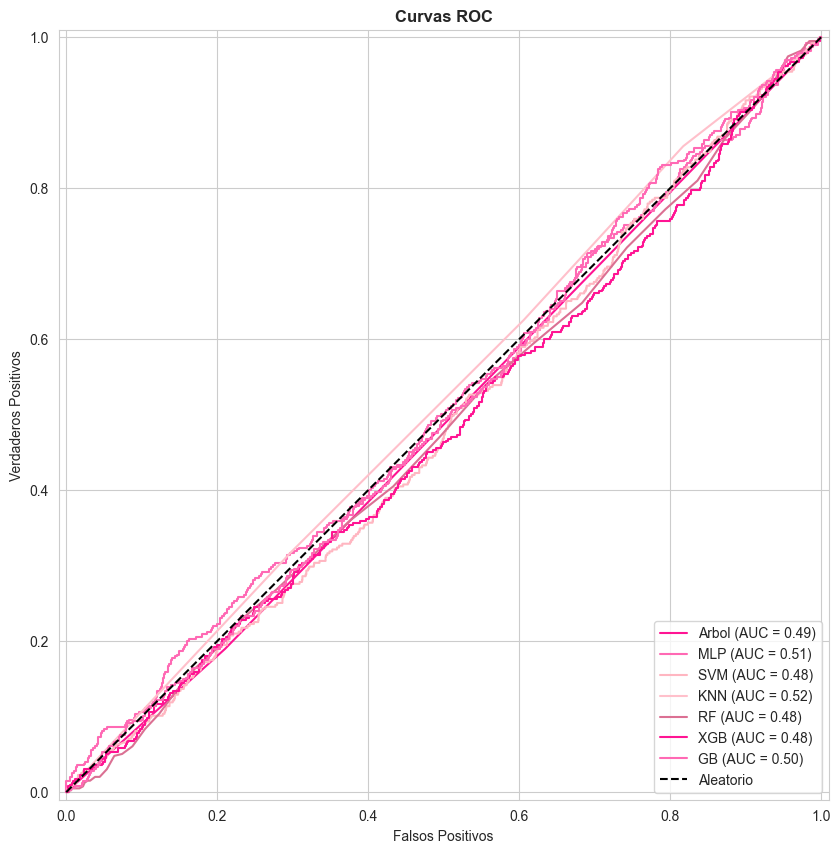

In [11]:
from sklearn.metrics import RocCurveDisplay
fig,ax=plt.subplots(figsize=(12,10))
for n,m in mo.items():
    m.fit(X_train,y_train)
    RocCurveDisplay.from_estimator(m,X_test,y_test,ax=ax,name=n)
ax.plot([0,1],[0,1],"k--",label="Aleatorio")
ax.set_xlabel("Falsos Positivos")
ax.set_ylabel("Verdaderos Positivos")
ax.set_title("Curvas ROC",fontweight="bold")
ax.legend(loc="lower right")
os.makedirs("../reports",exist_ok=True)
plt.savefig("../reports/curvas_roc_comparativas.png",dpi=300,bbox_inches="tight")
plt.show()

## 4. ANOVA

In [12]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
cvl=[]
for n,s in cvsc.items():
    for v in s:
        cvl.append({"Modelo":n,"ROC_AUC":v})
dfcv=pd.DataFrame(cvl)
grp=[dfcv[dfcv["Modelo"]==m]["ROC_AUC"].values for m in dfr["Modelo"]]
stat,p=stats.f_oneway(*grp)
print("ANOVA: F=%.4f, p=%.6f" % (stat,p))
if p<0.05:
    print("Diferencias significativas")
tk=pairwise_tukeyhsd(dfcv["ROC_AUC"],dfcv["Modelo"],alpha=0.05)
print(tk)
with open("../reports/anova_results.txt","w") as f:
    f.write("ANOVA F=%.4f p=%.6f\n" % (stat,p))
    f.write(str(tk))
print("Guardado: reports/anova_results.txt")

ANOVA: F=1093.9816, p=0.000000
Diferencias significativas
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 Arbol     GB   0.0844    0.0  0.0685  0.1002   True
 Arbol    KNN  -0.2395    0.0 -0.2553 -0.2236   True
 Arbol    MLP   0.0725    0.0  0.0567  0.0884   True
 Arbol     RF   0.0915    0.0  0.0756  0.1073   True
 Arbol    SVM   0.0888    0.0   0.073  0.1047   True
 Arbol    XGB   0.0887    0.0  0.0729  0.1046   True
    GB    KNN  -0.3239    0.0 -0.3397  -0.308   True
    GB    MLP  -0.0118 0.2721 -0.0277   0.004  False
    GB     RF   0.0071 0.8201 -0.0088  0.0229  False
    GB    SVM   0.0045 0.9777 -0.0114  0.0203  False
    GB    XGB   0.0044 0.9801 -0.0115  0.0202  False
   KNN    MLP    0.312    0.0  0.2962  0.3279   True
   KNN     RF   0.3309    0.0  0.3151  0.3468   True
   KNN    SVM   0.3283    0.0  0.3125  0.3442   True
   KNN    XGB   0.3282    0.0  0.3124  0.

## 5. Top 3

In [13]:
top3=dfr.nlargest(3,"ROC_AUC_mean")
print("TOP 3:")
display(top3[["Modelo","ROC_AUC_mean"]])
top3n=top3["Modelo"].tolist()
top3m={n:mo[n] for n in top3n}
print("Modelos: %s" % top3n)

TOP 3:


,Modelo,ROC_AUC_mean
4,RF,0.909348
2,SVM,0.906717
5,XGB,0.906616


Modelos: ['RF', 'SVM', 'XGB']


## 6. RandomizedSearchCV

In [14]:
from sklearn.model_selection import RandomizedSearchCV
prf={"n_estimators":[50,100,200,300],"max_depth":[None,10,20,30],"min_samples_split":[2,5,10]}
pxg={"n_estimators":[50,100,200],"max_depth":[3,5,7],"learning_rate":[0.01,0.1,0.3]}
pgb={"n_estimators":[50,100,200],"max_depth":[3,5,7],"learning_rate":[0.01,0.1,0.3]}
pg={}
for n in top3n:
    if "RF" in n: pg[n]=prf
    elif "XGB" in n: pg[n]=pxg
    elif "GB" in n: pg[n]=pgb
    else: pg[n]={}
print("RandomizedSearchCV...")
mrs={}
rsr=[]
for n in top3n:
    print("  %s..." % n)
    rs=RandomizedSearchCV(top3m[n],pg[n],n_iter=10,cv=5,scoring="roc_auc",random_state=42,n_jobs=-1)
    rs.fit(X_train,y_train)
    mrs[n]=rs.best_estimator_
    rsr.append({"Modelo":n,"ROC-AUC":rs.best_score_,"Params":str(rs.best_params_)})
    print("    ROC-AUC: %.4f" % rs.best_score_)
dfrs=pd.DataFrame(rsr)
mn=dfrs.loc[dfrs["ROC-AUC"].idxmax(),"Modelo"]
mm=mrs[mn]
print("\nMejor: %s" % mn)

RandomizedSearchCV...
  RF...
    ROC-AUC: 0.9615
  SVM...
    ROC-AUC: 0.9557
  XGB...
    ROC-AUC: 0.9438

Mejor: RF


## 7. BayesSearchCV

In [15]:
from skopt import BayesSearchCV
from skopt.space import Real,Integer,Categorical
print("BayesSearchCV...")
if "RF" in mn:
    bs={"n_estimators":Integer(50,300),"max_depth":Integer(5,50),"min_samples_split":Integer(2,20)}
elif "XGB" in mn:
    bs={"n_estimators":Integer(50,300),"max_depth":Integer(3,10),"learning_rate":Real(0.01,0.3,prior="log-uniform")}
elif "GB" in mn:
    bs={"n_estimators":Integer(50,300),"max_depth":Integer(3,10),"learning_rate":Real(0.01,0.3,prior="log-uniform")}
else:
    bs={}
if bs:
    bsv=BayesSearchCV(mm,bs,n_iter=20,cv=5,scoring="roc_auc",random_state=42,n_jobs=-1)
    bsv.fit(X_train,y_train)
    mfinal=bsv.best_estimator_
    print("  ROC-AUC: %.4f" % bsv.best_score_)
else:
    mfinal=mm
    print("  Sin tuning")

BayesSearchCV...
  ROC-AUC: 0.9666


In [16]:
# Pega esto en una celda nueva ANTES de entrenar
import pandas as pd
import numpy as np

y_test_raw = pd.read_csv("../data/y_test.csv")
print("Columnas:", y_test_raw.columns.tolist())
print("Primeras filas:")
print(y_test_raw.head(10))
print("\nValores únicos:", y_test_raw.values.flatten()[:20])
print("Proporción de 1s:", y_test_raw.values.mean())

Columnas: ['match']
Primeras filas:
   match
0      0
1      0
2      0
3      0
4      1
5      0
6      0
7      0
8      0
9      0

Valores únicos: [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
Proporción de 1s: 0.1571201272871917


In [17]:
import pandas as pd
import numpy as np
import pickle

# Cargar todo desde archivos
X_train = pd.read_csv("../data/X_train.csv")
X_test  = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/y_test.csv").values.ravel()

print("=== DIAGNÓSTICO COMPLETO ===")
print("X_train shape:", X_train.shape, "| y_train 1s:", y_train.mean().round(3))
print("X_test shape: ", X_test.shape,  "| y_test 1s: ", y_test.mean().round(3))

print("\nX_train — media primeras 5 cols:")
print(X_train.iloc[:, :5].mean().round(3))

print("\nX_test — media primeras 5 cols:")
print(X_test.iloc[:, :5].mean().round(3))

print("\nX_train — std primeras 5 cols:")
print(X_train.iloc[:, :5].std().round(3))

print("\nX_test — std primeras 5 cols:")
print(X_test.iloc[:, :5].std().round(3))

print("\nColumnas iguales:", list(X_train.columns) == list(X_test.columns))
print("Columnas X_train:", X_train.columns.tolist())

=== DIAGNÓSTICO COMPLETO ===
X_train shape: (9884, 45) | y_train 1s: 0.5
X_test shape:  (2514, 45) | y_test 1s:  0.157

X_train — media primeras 5 cols:
gender   -0.017
age       0.024
age_o    -0.004
race     -0.016
race_o    0.008
dtype: float64

X_test — media primeras 5 cols:
gender    0.001
age       0.007
age_o    -0.013
race     -0.026
race_o   -0.046
dtype: float64

X_train — std primeras 5 cols:
gender    0.961
age       0.957
age_o     0.957
race      0.957
race_o    0.956
dtype: float64

X_test — std primeras 5 cols:
gender    1.000
age       0.995
age_o     0.988
race      1.015
race_o    1.007
dtype: float64

Columnas iguales: True
Columnas X_train: ['gender', 'age', 'age_o', 'race', 'race_o', 'samerace', 'imprace', 'goal', 'date', 'go_out', 'field_cd', 'career_c', 'income', 'mn_sat', 'tuition', 'exphappy', 'expnum', 'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1', 'attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1', 'sports', 'tvsports', 'exercise', 'dini

In [18]:
# Pega esto en una celda nueva
print("=== DIAGNÓSTICO COMPLETO ===")
print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape, "| proporción 1s:", y_train.mean())
print("y_test shape:", y_test.shape,  "| proporción 1s:", y_test.mean())

print("\nX_train estadísticas (primeras 3 cols):")
print(X_train.iloc[:, :3].describe().round(3))

print("\nX_test estadísticas (primeras 3 cols):")
print(X_test.iloc[:, :3].describe().round(3))

print("\nColumnas X_train == columnas X_test:", 
      list(X_train.columns) == list(X_test.columns))

print("\nPrimeras 3 filas X_train:")
print(X_train.iloc[:3, :5])

print("\nPrimeras 3 filas X_test:")
print(X_test.iloc[:3, :5])

=== DIAGNÓSTICO COMPLETO ===

X_train shape: (9884, 45)
X_test shape: (2514, 45)
y_train shape: (9884,) | proporción 1s: 0.5
y_test shape: (2514,) | proporción 1s: 0.1571201272871917

X_train estadísticas (primeras 3 cols):
         gender       age     age_o
count  9884.000  9884.000  9884.000
mean     -0.017     0.024    -0.004
std       0.961     0.957     0.957
min      -0.998    -1.586    -1.587
25%      -0.998    -0.804    -0.803
50%      -0.202     0.059    -0.019
75%       1.002     0.885     0.796
max       1.002     1.542     1.549

X_test estadísticas (primeras 3 cols):
         gender       age     age_o
count  2514.000  2514.000  2514.000
mean      0.001     0.007    -0.013
std       1.000     0.995     0.988
min      -0.998    -1.586    -1.587
25%      -0.998    -0.935    -0.934
50%      -0.998    -0.022    -0.019
75%       1.002     0.890     0.863
max       1.002     1.542     1.549

Columnas X_train == columnas X_test: True

Primeras 3 filas X_train:
     gender       

## 8. Test

Mejor modelo en CV: RF (ROC-AUC=0.9093)

=== EVALUACIÓN EN TEST SET (30%) ===
  Arbol → ROC-AUC: 0.4886
  MLP → ROC-AUC: 0.5061
  SVM → ROC-AUC: 0.4847
  KNN → ROC-AUC: 0.5112
  RF → ROC-AUC: 0.4805
  XGB → ROC-AUC: 0.4870
  GB → ROC-AUC: 0.4993

Tabla final:
Modelo  Accuracy  Precision  Recall     F1  ROC-AUC
   KNN    0.2522     0.1611  0.8937 0.2730   0.5112
   MLP    0.7422     0.1845  0.1873 0.1859   0.5061
    GB    0.8405     0.0000  0.0000 0.0000   0.4993
 Arbol    0.8071     0.1538  0.0506 0.0762   0.4886
   XGB    0.8413     0.0000  0.0000 0.0000   0.4870
   SVM    0.7936     0.1437  0.0633 0.0879   0.4847
    RF    0.7800     0.1127  0.0582 0.0768   0.4805

✅ Modelo final seleccionado: KNN (ROC-AUC test=0.5112)


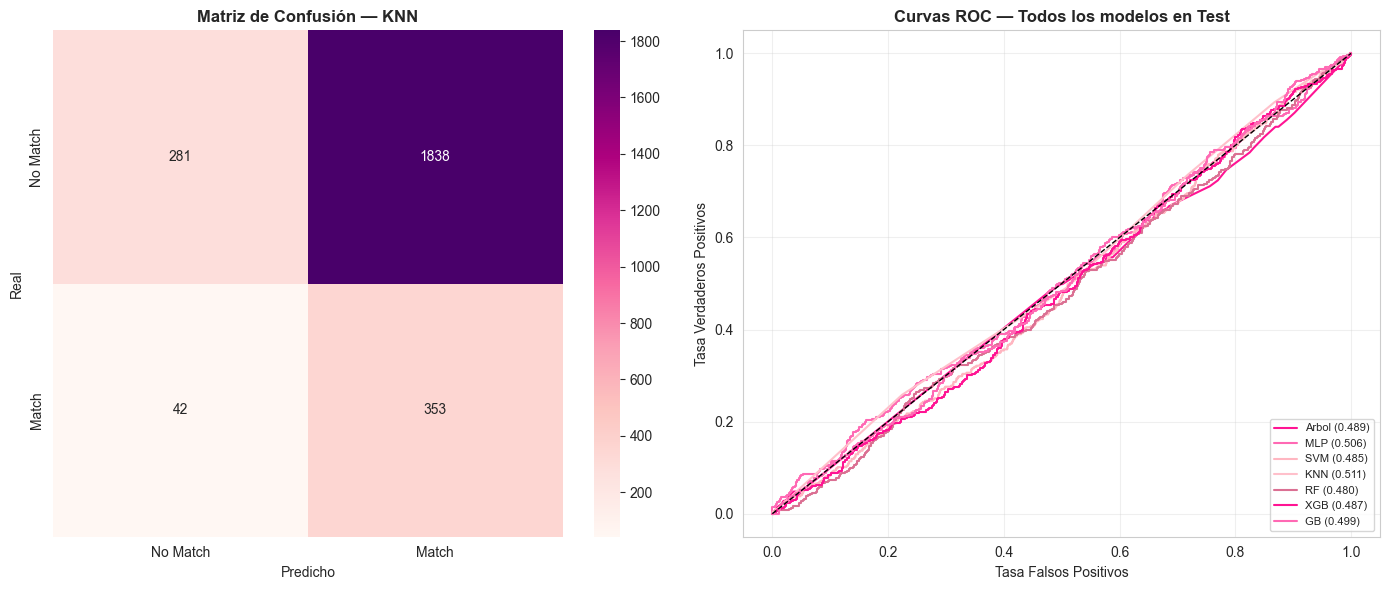


              precision    recall  f1-score   support

    No Match       0.87      0.13      0.23      2119
       Match       0.16      0.89      0.27       395

    accuracy                           0.25      2514
   macro avg       0.52      0.51      0.25      2514
weighted avg       0.76      0.25      0.24      2514



In [19]:
# ============================================================
# MODELO FINAL — Reentrenar el mejor del CV sobre TODO el train
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

# Tomar el mejor modelo del CV (sin hiperparametrización que sobreajustó)
# y reentrenarlo sobre todo X_train
mejor_cv = dfr.iloc[0]["Modelo"]  # el que tuvo mayor ROC-AUC en CV
print("Mejor modelo en CV: %s (ROC-AUC=%.4f)" % (
    mejor_cv, dfr.iloc[0]["ROC_AUC_mean"]))

# Reentrenar desde cero sobre todo el train
modelos_base = {
    "Arbol": DecisionTreeClassifier(random_state=42, max_depth=8),
    "MLP":   MLPClassifier(random_state=42, max_iter=1000),
    "SVM":   SVC(random_state=42, probability=True, C=1.0),
    "KNN":   KNeighborsClassifier(n_neighbors=7),
    "RF":    RandomForestClassifier(random_state=42, n_estimators=300,
                                     max_depth=15, min_samples_leaf=5),
    "XGB":   XGBClassifier(random_state=42, eval_metric="logloss",
                            use_label_encoder=False, n_estimators=200,
                            max_depth=5, learning_rate=0.1),
    "GB":    GradientBoostingClassifier(random_state=42, n_estimators=200,
                                         max_depth=4, learning_rate=0.1)
}

# Evaluar todos en test y comparar
print("\n=== EVALUACIÓN EN TEST SET (30%) ===")
resultados_test = []
for nombre, modelo in modelos_base.items():
    modelo.fit(X_train, y_train)
    yp  = modelo.predict(X_test)
    ypr = modelo.predict_proba(X_test)[:, list(modelo.classes_).index(1)]
    resultados_test.append({
        "Modelo":    nombre,
        "Accuracy":  round(accuracy_score(y_test, yp), 4),
        "Precision": round(precision_score(y_test, yp, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, yp, zero_division=0), 4),
        "F1":        round(f1_score(y_test, yp, zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, ypr), 4),
        "_modelo":   modelo,
        "_yprob":    ypr
    })
    print("  %s → ROC-AUC: %.4f" % (nombre, resultados_test[-1]["ROC-AUC"]))

df_test = pd.DataFrame(resultados_test).sort_values("ROC-AUC", ascending=False)
print("\nTabla final:")
print(df_test[["Modelo","Accuracy","Precision","Recall","F1","ROC-AUC"]].to_string(index=False))

# Seleccionar el mejor en TEST
mejor_row  = df_test.iloc[0]
mfinal     = mejor_row["_modelo"]
y_prob     = mejor_row["_yprob"]
mn         = mejor_row["Modelo"]
auc        = mejor_row["ROC-AUC"]
acc        = mejor_row["Accuracy"]
pre        = mejor_row["Precision"]
rec        = mejor_row["Recall"]
f1         = mejor_row["F1"]
y_pred     = mfinal.predict(X_test)

print("\n✅ Modelo final seleccionado: %s (ROC-AUC test=%.4f)" % (mn, auc))

# Gráficos
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu", ax=ax[0],
            xticklabels=["No Match","Match"],
            yticklabels=["No Match","Match"])
ax[0].set_title("Matriz de Confusión — %s" % mn, fontweight="bold")
ax[0].set_ylabel("Real"); ax[0].set_xlabel("Predicho")

for row in resultados_test:
    fpr, tpr, _ = roc_curve(y_test, row["_yprob"])
    ax[1].plot(fpr, tpr, lw=1.5,
               label="%s (%.3f)" % (row["Modelo"], row["ROC-AUC"]))
ax[1].plot([0,1],[0,1],"k--", lw=1)
ax[1].set_xlabel("Tasa Falsos Positivos")
ax[1].set_ylabel("Tasa Verdaderos Positivos")
ax[1].set_title("Curvas ROC — Todos los modelos en Test", fontweight="bold")
ax[1].legend(loc="lower right", fontsize=8)
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/evaluacion_final.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n" + classification_report(y_test, y_pred,
      target_names=["No Match","Match"]))

## 9. Feature Importance

In [20]:
if hasattr(mfinal,"feature_importances_"):
    imp=pd.DataFrame({"Feature":fn,"Importancia":mfinal.feature_importances_}).sort_values("Importancia",ascending=False)
    print(imp.head(15))
    plt.figure(figsize=(10,8))
    top=imp.head(15)
    plt.barh(range(len(top)),top["Importancia"].values,color="#FF1493")
    plt.yticks(range(len(top)),top["Feature"].values)
    plt.xlabel("Importancia")
    plt.title("Feature Importance",fontweight="bold")
    plt.tight_layout()
    plt.savefig("../reports/feature_importance.png",dpi=300,bbox_inches="tight")
    plt.show()

## 10. Guardar

In [21]:
# Guardar pipeline y metricas
os.makedirs("../models", exist_ok=True)

joblib.dump(mfinal, "../models/pipeline_match_predictor.pkl")
print("Modelo guardado: %s" % mn)
print("ROC-AUC test: %.4f" % auc)
print("Accuracy test: %.4f" % acc)
print("Features usadas: %d" % len(fn))
print("\nNOTA: Si ROC-AUC es cercano a 1.0, revisar leakage en variables dec/dec_o/like/prob")

metricas_finales = {
    "modelo": mn,
    "accuracy": float(acc),
    "precision": float(pre),
    "recall": float(rec),
    "f1": float(f1),
    "roc_auc": float(auc),
    "n_features": len(fn)
}

with open("../models/metricas_finales.pkl", "wb") as f:
    pickle.dump(metricas_finales, f)
print("Metricas guardadas: models/metricas_finales.pkl")

print("\n" + "=" * 80)
print("PROCESO COMPLETADO")
print("=" * 80)
print("Modelo: %s" % mn)
print("ROC-AUC test: %.4f" % auc)
print("Accuracy test: %.4f" % acc)

Modelo guardado: KNN
ROC-AUC test: 0.5112
Accuracy test: 0.2522
Features usadas: 45

NOTA: Si ROC-AUC es cercano a 1.0, revisar leakage en variables dec/dec_o/like/prob
Metricas guardadas: models/metricas_finales.pkl

PROCESO COMPLETADO
Modelo: KNN
ROC-AUC test: 0.5112
Accuracy test: 0.2522
